In [134]:
# Set up Python Facilities
import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy.optimize import curve_fit
from scipy import stats
from scipy.stats import poisson
from scipy.stats import norm
import math
import pandas as pd
%matplotlib inline

In [135]:
#Identifying and reading the data
df = pd.read_csv("part1data.csv")
df = df.iloc[1:]
df

,Resistance Uncertainty,Resistance,Digits of resistance,Voltage,Voltage Uncertainty
1,11960.0000,996000.0,3,9.520,0.067600
2,21940.0000,1994000.0,4,9.520,0.067600
3,998.4000,99800.0,3,9.540,0.067700
4,99.8400,9980.0,3,9.490,0.067450
5,9.9840,998.0,3,9.270,0.066350
6,17.9360,1992.0,4,9.360,0.066800
7,60.7200,5090.0,3,9.450,0.067250
8,68.7200,6090.0,3,9.470,0.067350
9,4.6240,328.0,3,9.050,0.065250
10,12.6160,1327.0,4,9.320,0.066600


In [151]:
voltage = df["Voltage"]
dvoltage = df["Voltage Uncertainty"]

resistance = df["Resistance"]
dresistance = df["Resistance Uncertainty"]

# v = IR
# I = R 
current = voltage / resistance

dcurrent = np.sqrt( (dvoltage * (1/resistance) ) ** 2 + (dresistance * ( - voltage) * (1 / (resistance ** 2))) ** 2)

y_var =  current
y_uncertainty = dcurrent

x_var = voltage
x_uncertainty = dvoltage

In [137]:
np.sqrt( (dvoltage * (1/resistance) ) ** 2 + (dresistance * ( - voltage) * (1 / (resistance ** 2))) ** 2)

1     1.333416e-07
2     6.252142e-08
3     1.172462e-06
4     1.166925e-05
5     1.142570e-04
6     5.398618e-05
7     2.578916e-05
8     2.074114e-05
9     4.368910e-04
10    8.353085e-05
11    7.584079e-04
12    2.292290e-04
13    1.054598e-03
14    8.688808e-04
15    3.961017e-03
16    2.210041e-03
17    6.291836e-03
18    2.834633e-03
19    3.951049e-03
20    6.887712e-04
21    1.814999e-03
22    1.537073e-03
23    1.513194e-02
24    3.567352e-02
25    5.475647e-02
26    7.707155e-02
27    1.658393e-01
28    2.459832e-01
29    8.628553e-03
30    2.051936e-02
dtype: float64

In [152]:
# for x, y in zip(x_var, y_var):
#     print(x, ",", y)

In [139]:
#Preparing the Plots
x_label = "Voltage"
y_label = "Current (A)"
title = "Voltage to current of battery FIX THIS"
xmax = max(x_var) * 1.05
xmin = 0 # min(x_var) - (xmax * 0.05)

ymin = min(y_var) * 0.95
ymax = max(y_var) * 1.05

Now lets make a graph of y_var vs. x_var, with error bars on the y data.

Text(0.5, 1.0, 'Voltage to current of battery FIX THIS')

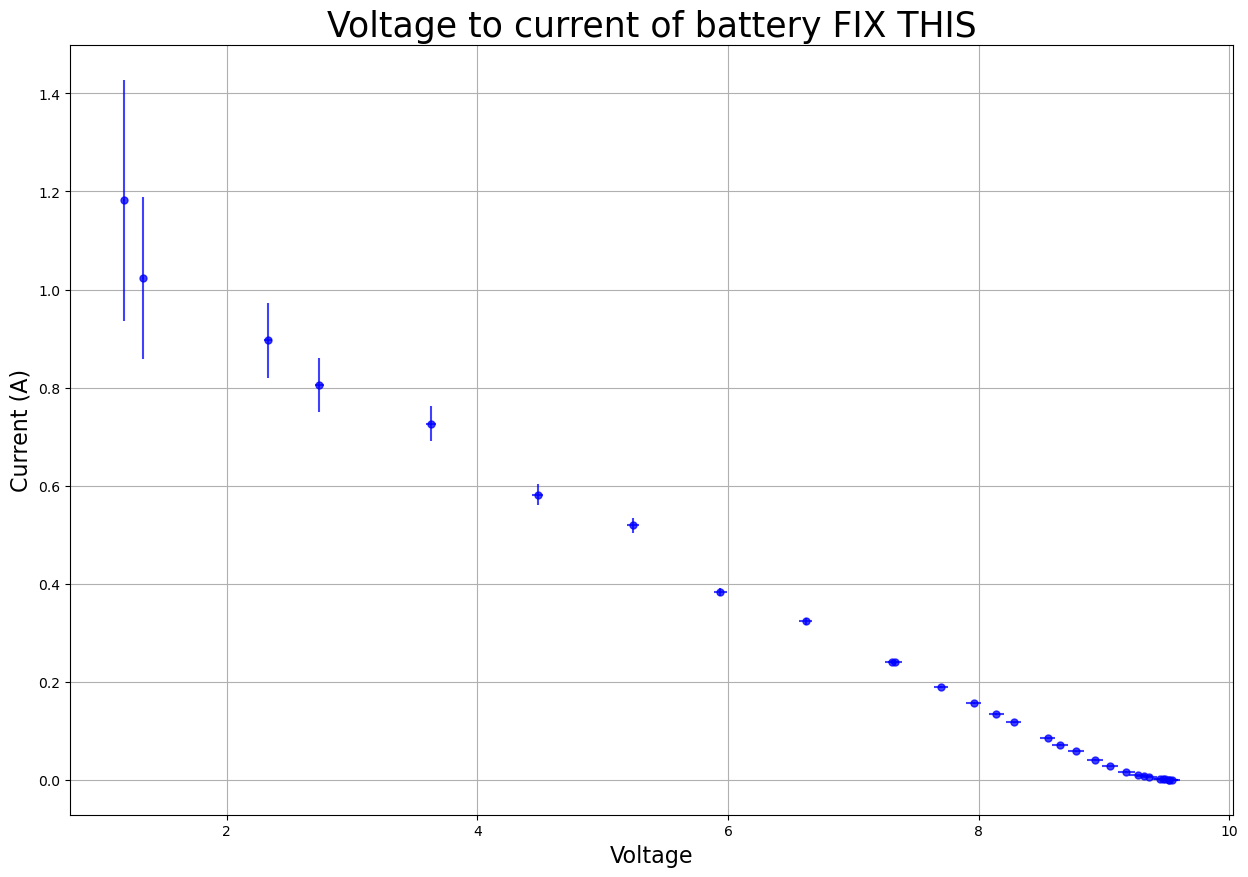

In [153]:
plt.errorbar(x_var, y_var, yerr=y_uncertainty, xerr=x_uncertainty, fmt="o", ms=5, color="blue", alpha=0.75)

plt.gcf().set_size_inches(15, 10)  # This sets the size of the plot
plt.grid(True)  # This toggles whether gridlines are displayed
plt.xlabel(x_label, fontsize=16)  # x-axis label
plt.ylabel(y_label, fontsize=16)  # y-axis label
plt.title(title, fontsize=25)  # Plot title

# To manually change the axis limits, uncomment (remove the # at the start) these lines:
#plt.ylim(ymin, ymax)  # This sets the range of the y-axis
#plt.xlim(xmin, xmax)  # This sets the range of the x-axis

# To save the plot as a .png, uncomment this:
#plt.savefig("plot", bbox_inches="tight", dpi=300)  # Saves the figure

In [141]:
def FitFunction(x, m, b):
    y = m * x + b
    return y

n_parameters = 2

In [142]:
#Parameter Bounds ([lower bounds,...],[Upper bounds,...])
param_bounds=([-np.inf,-np.inf],[np.inf,np.inf])  
initial_param=(1,1)  

In [143]:
cut = 15
optimized_parameters, covariance_matrix = curve_fit(FitFunction, x_var[cut:],y_var[cut:],
                                                    sigma=y_uncertainty[cut:],absolute_sigma=True,
                                                    bounds=param_bounds,p0=initial_param)
parameter_errors = np.sqrt(np.diag(covariance_matrix))

## Plotting the fit results:

In [144]:
for i in range(len(optimized_parameters)):
    print(f'Parameter #{i+1}: {optimized_parameters[i]:.6e} ± {parameter_errors[i]:.1e}')

Parameter #1: -1.212837e-01 ± 1.2e-03
Parameter #2: 1.122707e+00 ± 9.8e-03


In [145]:
# First calculate a reasonable range of x values for our line
x_length = max(x_var) - min(x_var)
x_min_l = min(x_var) - 0.05*x_length
x_max_l = max(x_var) + 0.05*x_length
# Create our array of 200 linearly-spaced points
xForLine = np.linspace(x_min_l,x_max_l,200)
# Calculate the y values of the best fit line
yForLine = FitFunction(xForLine,*optimized_parameters)

Now we are ready to plot the fit function with our data. We repeat the code to plot the previous graph, and then plot our fit function.

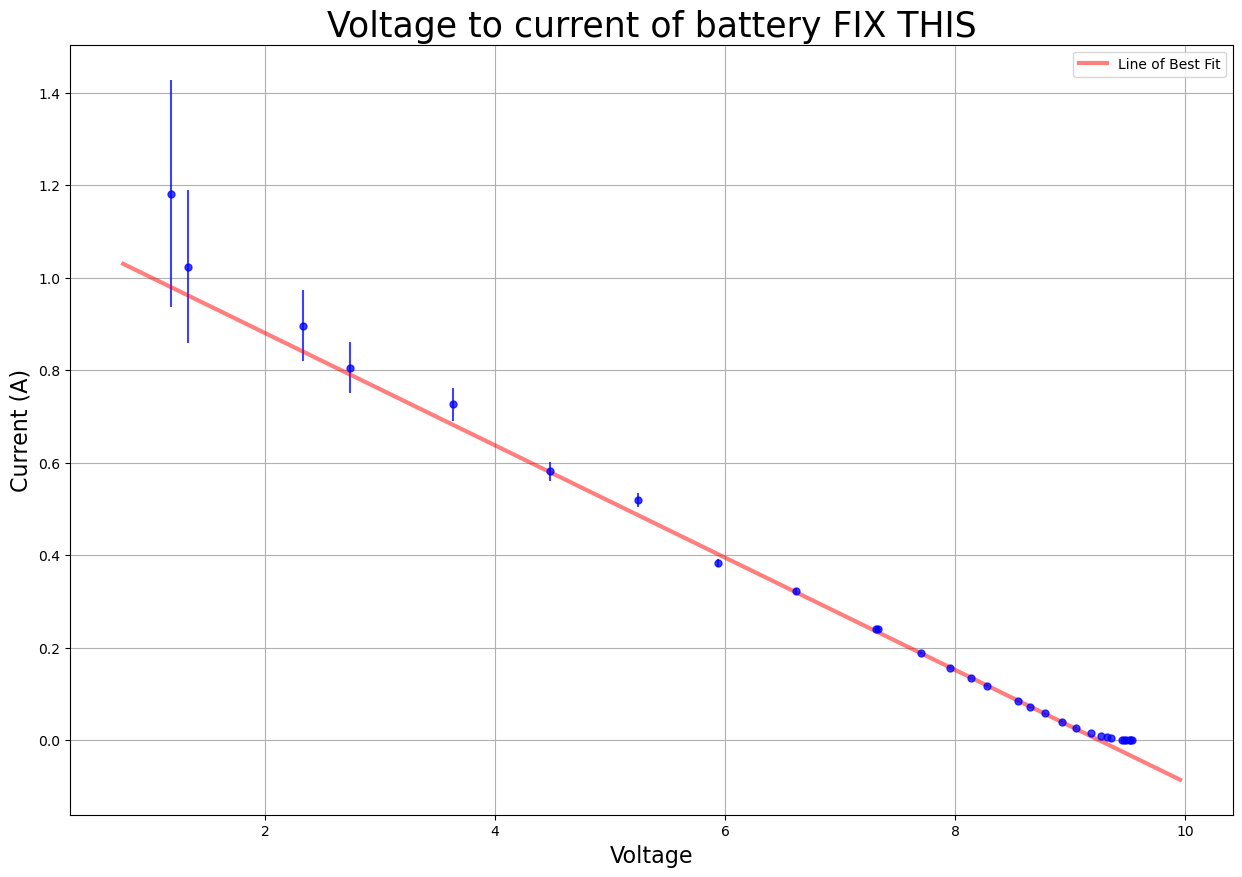

In [146]:
# Plot our data
plt.errorbar(x_var, y_var, yerr=y_uncertainty, fmt="o", ms=5, color="blue", alpha=0.75)

# Add grid lines, titles, and axis labels.
plt.gcf().set_size_inches(15, 10)  # This sets the size of the plot
plt.grid(True)  # This toggles whether gridlines are displayed
plt.xlabel(x_label, fontsize=16)  # x-axis label
plt.ylabel(y_label, fontsize=16)  # y-axis label
plt.title(title, fontsize=25)  # Plot title

# To manually change the axis limits, uncomment (remove the # at the start) these lines:
#plt.ylim(ymin, ymax)  # This sets the range of the y-axis
#plt.xlim(xmin, xmax)  # This sets the range of the x-axis

# Add the line to the plot
plt.plot(xForLine, yForLine, lw=3, color="red", alpha=0.5, label="Line of Best Fit")

# Add a legend
plt.legend()

# To save the plot as a .png, uncomment this:
#plt.savefig("plot_fit", bbox_inches="tight", dpi=300)  # Saves the figure

In [147]:
residual = y_var - FitFunction(x_var,*optimized_parameters)

(0.0, 10.017)

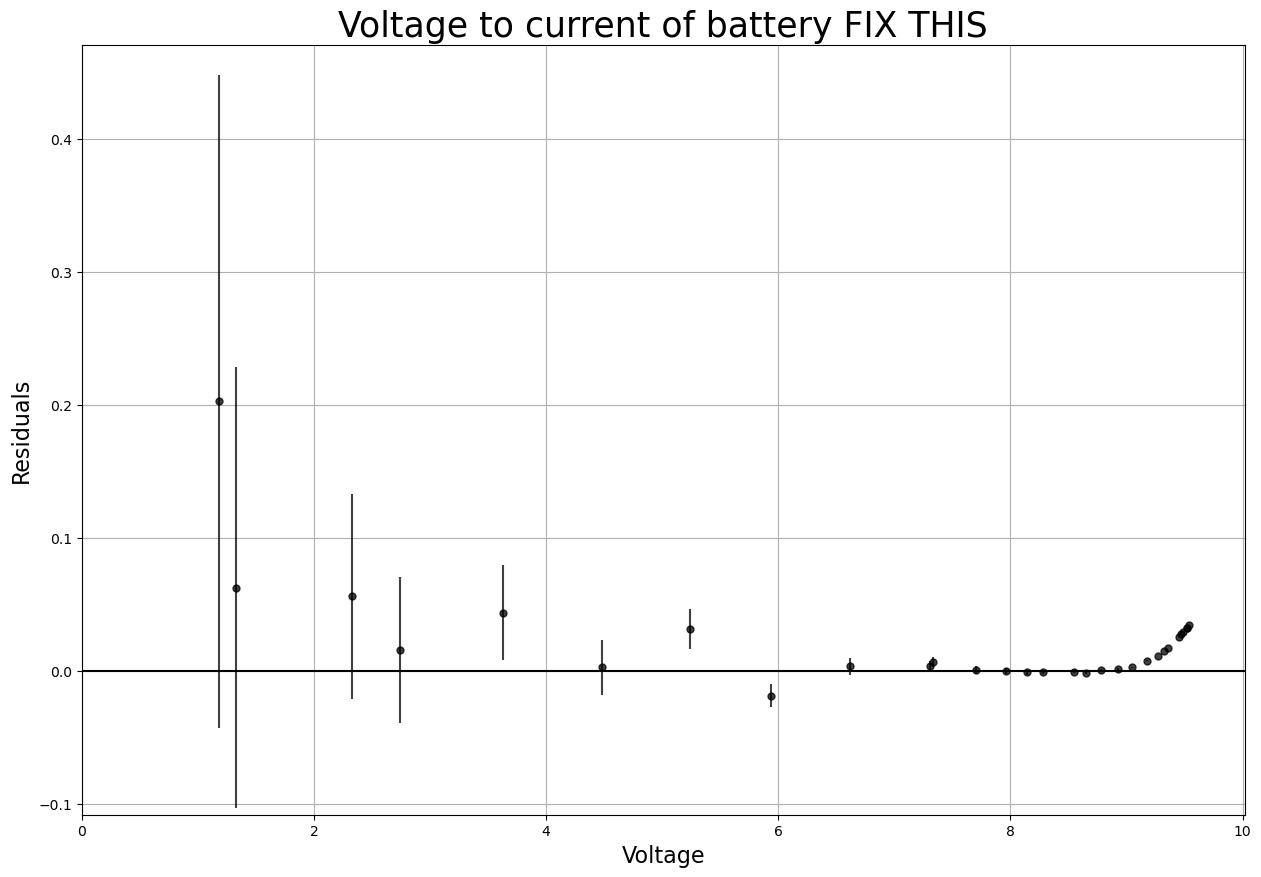

In [148]:
# Plot the residuals
plt.errorbar(x_var, residual, yerr=y_uncertainty, fmt="o", ms=5, color="black", alpha=0.75)

# Add grid lines, titles, and axis labels.
plt.gcf().set_size_inches(15, 10)  # This sets the size of the plot
plt.grid(True)  # This toggles whether gridlines are displayed
plt.xlabel(x_label, fontsize=16)  # x-axis label
plt.ylabel("Residuals", fontsize=16)  # y-axis label
plt.title(title, fontsize=25)  # Plot title

plt.axhline(0, color="black")


# Set the axis limits for the residuals plot
ymin_r= min(residual - y_uncertainty) * 1.05
ymax_r= max(residual + y_uncertainty) * 1.05
plt.ylim(ymin_r, ymax_r)  # This sets the range of the y-axis
plt.xlim(xmin, xmax)  # This sets the range of the x-axis

# To save the plot as a .png, uncomment this:
#plt.savefig("plot_residuals", bbox_inches="tight", dpi=300)  # Saves the figure

Lets also calculate the $\chi^2$ value for our fit. This indicates the goodness-of-fit:
- $\chi^2>>1$ indicates the model is not a good fit to the data, or uncertainties are likely underestimated.
- $\chi^2\sim1$ indicates the model is a good fit to the data.
- $\chi^2<<1$ indicates the model is "too good" a fit, i.e. the uncertainties are likely overestimated.

In [149]:
ndof = len(x_var) - len(optimized_parameters) - 1 # Number of degrees of freedom ndof = no. entries - no. parameters -1
ru = residual / y_uncertainty
chisq = np.sum(np.power(ru, 2)) / ndof
print("Chisq", str.format("{0:.4f}", chisq))  # Print 4 significant figures

Chisq 11808509773.0442


In [150]:
ndof = len(x_var[cut:]) - len(optimized_parameters) - 1 # Number of degrees of freedom ndof = no. entries - no. parameters -1
ru = residual[cut:] / y_uncertainty[cut:]
chisq = np.sum(np.power(ru, 2)) / ndof
print("Corrected Chisq", str.format("{0:.4f}", chisq))  # Print 4 significant figures

Corrected Chisq 1.2486
